In [1]:
# Cell 1 — Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

All libraries imported successfully!
pandas: 3.0.2
numpy: 2.4.4
scikit-learn: 1.8.0


In [2]:
# Cell 2 — Load KDD Cup 99 dataset
from sklearn.datasets import fetch_kddcup99

print("Downloading dataset... please wait")
data = fetch_kddcup99(subset='SA', as_frame=True, percent10=True)
df = data.frame

print(f"Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset loaded!
Shape: (100655, 42)

First 5 rows:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,b'tcp',b'http',b'SF',181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,b'normal.'
1,0,b'tcp',b'http',b'SF',239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,b'normal.'
2,0,b'tcp',b'http',b'SF',235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,b'normal.'
3,0,b'tcp',b'http',b'SF',219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,b'normal.'
4,0,b'tcp',b'http',b'SF',217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,b'normal.'


In [3]:
# Cell 3 — Explore dataset
print("Dataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nLabel Distribution:")
print(df['labels'].value_counts())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 100655 entries, 0 to 100654
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   duration                     100655 non-null  object
 1   protocol_type                100655 non-null  object
 2   service                      100655 non-null  object
 3   flag                         100655 non-null  object
 4   src_bytes                    100655 non-null  object
 5   dst_bytes                    100655 non-null  object
 6   land                         100655 non-null  object
 7   wrong_fragment               100655 non-null  object
 8   urgent                       100655 non-null  object
 9   hot                          100655 non-null  object
 10  num_failed_logins            100655 non-null  object
 11  logged_in                    100655 non-null  object
 12  num_compromised              100655 non-null  object
 13  root_shell 

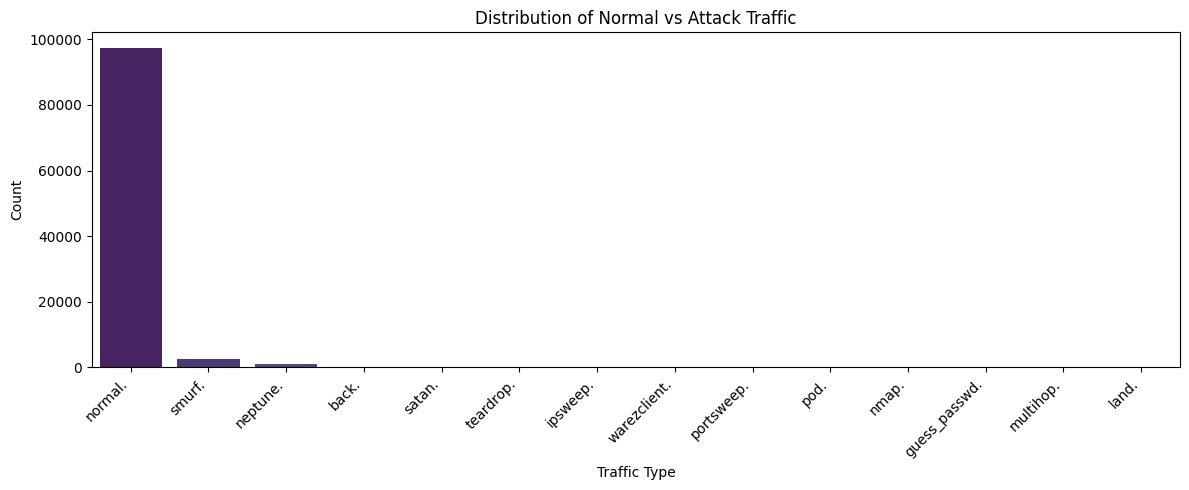


Total records: 100655
Unique labels: 14


In [4]:
# Cell 4 — Visualise label distribution
plt.figure(figsize=(12, 5))
label_counts = df['labels'].value_counts()
sns.barplot(x=label_counts.index, y=label_counts.values,
            hue=label_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Normal vs Attack Traffic')
plt.xlabel('Traffic Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nTotal records: {len(df)}")
print(f"Unique labels: {df['labels'].nunique()}")


In [5]:
# Cell 5 — Create binary label
df['is_attack'] = df['labels'].apply(
    lambda x: 0 if x == b'normal.' else 1
)

print("Binary label created!")
print(df['is_attack'].value_counts())
print(f"\nNormal: {(df['is_attack']==0).sum()}")
print(f"Attack: {(df['is_attack']==1).sum()}")
print(f"Imbalance ratio: {(df['is_attack']==0).sum() / (df['is_attack']==1).sum():.1f}:1")

Binary label created!
is_attack
0    97278
1     3377
Name: count, dtype: int64

Normal: 97278
Attack: 3377
Imbalance ratio: 28.8:1


In [6]:
# Cell 6 — Encode categorical features
from sklearn.preprocessing import LabelEncoder

df_clean = df.drop(columns=['labels'])

# Decode bytes to strings
for col in df_clean.columns:
    if df_clean[col].dtype == object:
        df_clean[col] = df_clean[col].apply(
            lambda x: x.decode('utf-8') if isinstance(x, bytes) else x
        )

# Encode text columns to numbers
le = LabelEncoder()
for col in df_clean.select_dtypes(include=['object', 'str']).columns:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

print("Encoding complete!")
print(f"Shape: {df_clean.shape}")
print(f"\nData types:")
print(df_clean.dtypes.value_counts())
df_clean.head(3)

Encoding complete!
Shape: (100655, 42)

Data types:
int64      27
float64    15
Name: count, dtype: int64


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,is_attack
0,0,1,18,8,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,0
1,0,1,18,8,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,0
2,0,1,18,8,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,0


In [7]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# Cell 7 — Handle class imbalance with SMOTE
from imblearn.over_sampling import SMOTE

X_raw = df_clean.drop(columns=['is_attack'])
y_raw = df_clean['is_attack']

print(f"Before SMOTE — Normal: {(y_raw==0).sum()}, Attack: {(y_raw==1).sum()}")

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_raw, y_raw)

print(f"After SMOTE  — Normal: {(y_resampled==0).sum()}, Attack: {(y_resampled==1).sum()}")
print(f"New dataset shape: {X_resampled.shape}")

Before SMOTE — Normal: 97278, Attack: 3377
After SMOTE  — Normal: 97278, Attack: 97278
New dataset shape: (194556, 41)


Top 20 features selected:
['count', 'srv_count', 'logged_in', 'protocol_type', 'dst_host_same_src_port_rate', 'dst_host_count', 'same_srv_rate', 'dst_host_srv_serror_rate', 'serror_rate', 'dst_host_serror_rate', 'srv_serror_rate', 'srv_diff_host_rate', 'dst_host_srv_diff_host_rate', 'flag', 'service', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'duration', 'dst_host_srv_count', 'dst_bytes']

Reduced shape: (194556, 20)


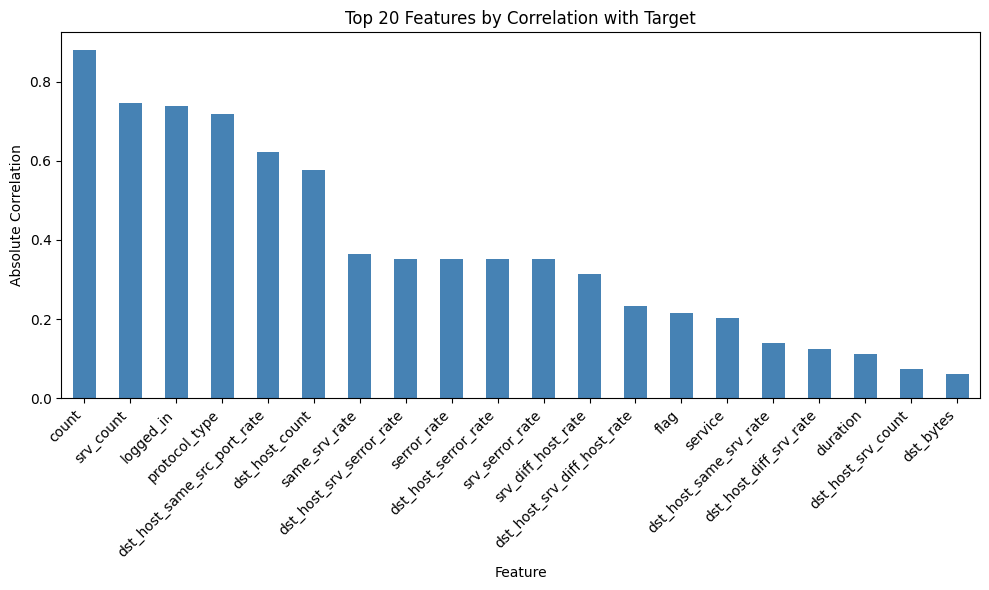

In [9]:
# Cell 8 — Feature selection using correlation
import pandas as pd

# Convert resampled data back to DataFrame
X_df = pd.DataFrame(X_resampled, columns=X_raw.columns)

# Calculate correlation with target
correlations = X_df.corrwith(pd.Series(y_resampled)).abs()
correlations = correlations.sort_values(ascending=False)

# Keep top 20 most correlated features
top_features = correlations.head(20).index.tolist()
print(f"Top 20 features selected:")
print(top_features)

X_selected = X_df[top_features]
print(f"\nReduced shape: {X_selected.shape}")

# Plot feature correlation
plt.figure(figsize=(10, 6))
correlations.head(20).plot(kind='bar', color='steelblue')
plt.title('Top 20 Features by Correlation with Target')
plt.xlabel('Feature')
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
# Cell 9 — Split and scale
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_resampled,
    test_size=0.2, random_state=42, stratify=y_resampled
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set:     {X_test_scaled.shape}")
print(f"Scaling done — mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")

Training set: (155644, 20)
Test set:     (38912, 20)
Scaling done — mean: -0.0000, std: 1.0000


In [11]:
!pip install xgboost


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
# Cell 10 — Train all 5 classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# Note — install xgboost first: pip install xgboost

models = {
    'Decision Tree':   DecisionTreeClassifier(random_state=42),
    'Random Forest':   RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':         XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    'KNN':             KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'SVM':             SVC(kernel='rbf', random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test_scaled)

    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'Train Time (s)': round(train_time, 2),
        'model': model,
        'predictions': y_pred
    }
    print(f"  Done — Accuracy: {results[name]['Accuracy']:.4f}, Time: {train_time:.2f}s")

print("\nAll models trained!")

Training Decision Tree...
  Done — Accuracy: 0.9996, Time: 0.58s
Training Random Forest...
  Done — Accuracy: 0.9998, Time: 6.03s
Training XGBoost...
  Done — Accuracy: 0.9998, Time: 0.67s
Training KNN...
  Done — Accuracy: 0.9991, Time: 0.02s
Training SVM...
  Done — Accuracy: 0.9960, Time: 25.08s

All models trained!


Model Comparison:
               Accuracy  Precision    Recall  F1-Score  Train Time (s)
Decision Tree  0.999615   0.999537  0.999692  0.999615            0.58
Random Forest  0.999846   1.000000  0.999692  0.999846            6.03
XGBoost        0.999820   0.999846  0.999794  0.999820            0.67
KNN            0.999101   0.998870  0.999332  0.999101            0.02
SVM            0.996042   0.999638  0.992444  0.996028           25.08


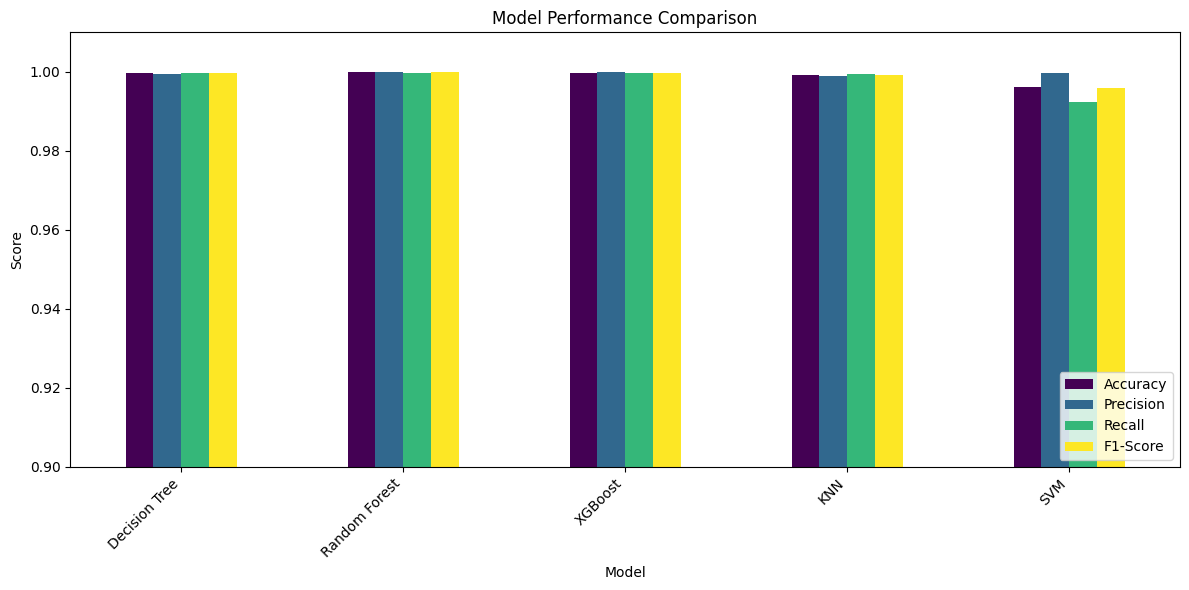

In [13]:
# Cell 11 — Compare all models
results_df = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k not in ['model', 'predictions']}
    for name, metrics in results.items()
}).T

print("Model Comparison:")
print(results_df.to_string())

# Plot comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
results_df[metrics_to_plot].plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.ylim(0.9, 1.01)
plt.tight_layout()
plt.show()

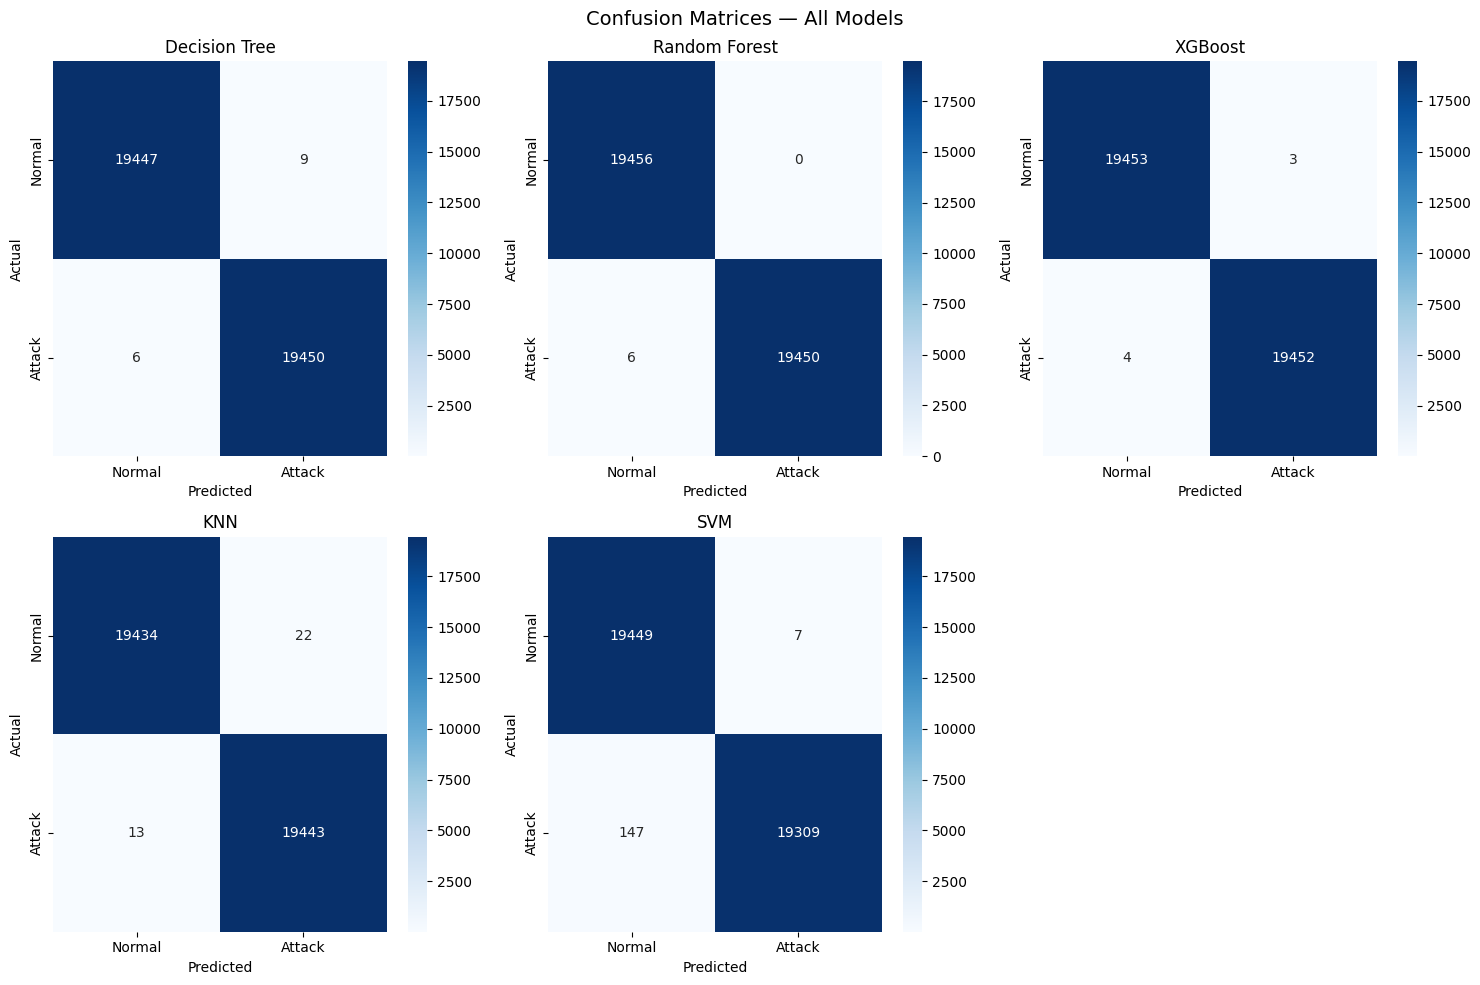

In [14]:
# Cell 12 — Confusion matrices
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, metrics) in enumerate(results.items()):
    cm = confusion_matrix(y_test, metrics['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'])
    axes[idx].set_title(f'{name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

axes[-1].set_visible(False)
plt.suptitle('Confusion Matrices — All Models', fontsize=14)
plt.tight_layout()
plt.show()

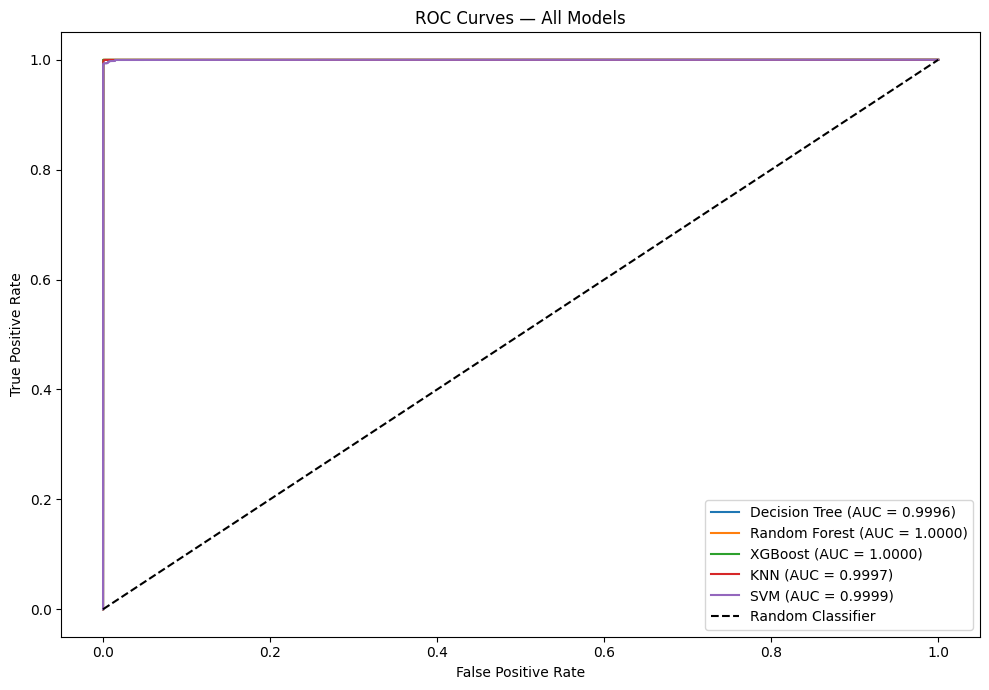

In [15]:
# Cell 13 — ROC curves
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

for name, metrics in results.items():
    model = metrics['model']
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


Calculating SHAP values for Random Forest...
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (200, 20, 2)
Using SHAP array shape: (200, 20)


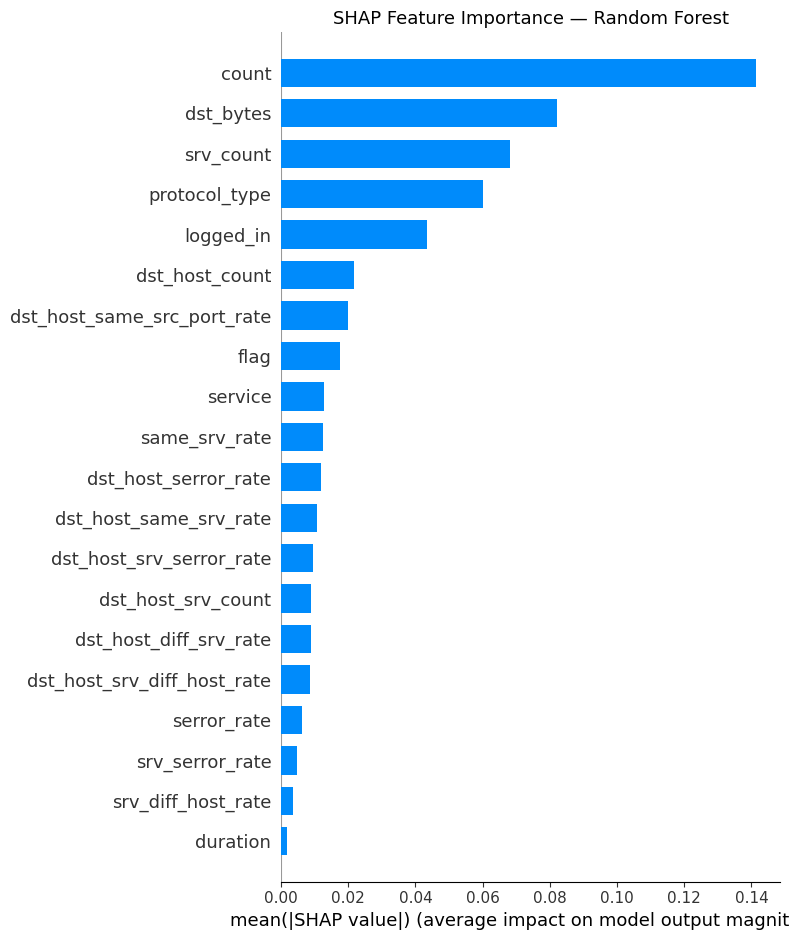

Done — Random Forest

Calculating SHAP values for XGBoost...
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (200, 20)
Using SHAP array shape: (200, 20)


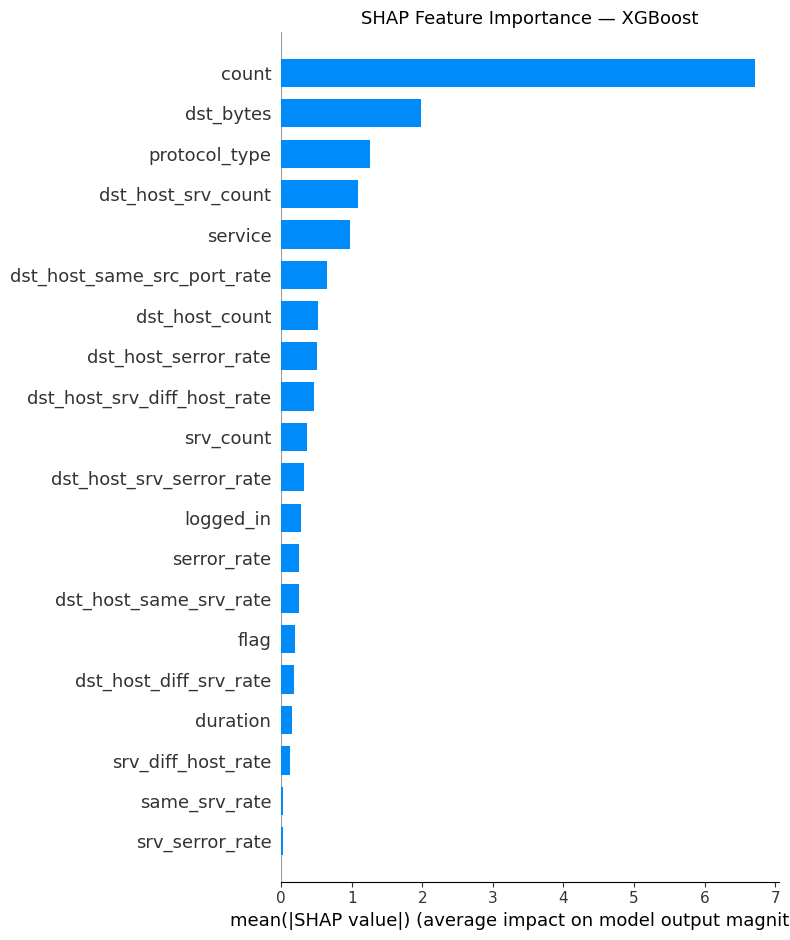

Done — XGBoost


In [19]:
# Cell 14 — SHAP for Random Forest and XGBoost (fixed)
import shap
import matplotlib.pyplot as plt
import pandas as pd

best_models = {
    'Random Forest': results['Random Forest']['model'],
    'XGBoost': results['XGBoost']['model']
}

X_sample = pd.DataFrame(X_test_scaled[:200], columns=top_features)

for name, model in best_models.items():
    print(f"\nCalculating SHAP values for {name}...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    print(f"SHAP values type: {type(shap_values)}")
    print(f"SHAP values shape: {shap_values.shape if hasattr(shap_values, 'shape') else [v.shape for v in shap_values]}")

    # Handle different SHAP output formats
    if isinstance(shap_values, list):
        # Old format — list of arrays, one per class
        # Index 1 = attack class
        sv = shap_values[1]
    elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
        # New format — 3D array (samples, features, classes)
        sv = shap_values[:, :, 1]
    else:
        # 2D array — already the right format
        sv = shap_values

    print(f"Using SHAP array shape: {sv.shape}")

    # Plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        sv,
        X_sample,
        feature_names=top_features,
        plot_type='bar',
        show=False
    )
    plt.title(f'SHAP Feature Importance — {name}', fontsize=13)
    plt.tight_layout()
    plt.show()
    print(f"Done — {name}")

In [17]:
# Cell 15 — Save models
import pickle
import os

os.makedirs('../src', exist_ok=True)

# Save both best models
with open('../src/rf_model.pkl', 'wb') as f:
    pickle.dump(results['Random Forest']['model'], f)

with open('../src/xgb_model.pkl', 'wb') as f:
    pickle.dump(results['XGBoost']['model'], f)

with open('../src/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../src/feature_names.pkl', 'wb') as f:
    pickle.dump(top_features, f)

# Save results to CSV
results_df.drop(columns=[], errors='ignore').to_csv('../src/model_results.csv')

print("All models and results saved!")
print("Files:")
print("  src/rf_model.pkl")
print("  src/xgb_model.pkl")
print("  src/scaler.pkl")
print("  src/feature_names.pkl")
print("  src/model_results.csv")

All models and results saved!
Files:
  src/rf_model.pkl
  src/xgb_model.pkl
  src/scaler.pkl
  src/feature_names.pkl
  src/model_results.csv


In [18]:
# Cell 16 — Test model on a random sample from test set

import random

# ✅ FIX: Get models from results dictionary
rf_model = results['Random Forest']['model']
xgb_model = results['XGBoost']['model']

# Pick a random index from test set
random_idx = random.randint(0, len(X_test_scaled) - 1)

# Get the sample
sample = X_test_scaled[random_idx].reshape(1, -1)
actual_label = y_test.iloc[random_idx]

# Predict with both models
rf_pred = rf_model.predict(sample)[0]
xgb_pred = xgb_model.predict(sample)[0]
rf_prob = rf_model.predict_proba(sample)[0][1]
xgb_prob = xgb_model.predict_proba(sample)[0][1]

# Display results
print(f"Random sample index: {random_idx}")
print(f"\nActual label:        {'ATTACK' if actual_label == 1 else 'NORMAL'}")
print(f"\nRandom Forest:       {'ATTACK' if rf_pred == 1 else 'NORMAL'} (confidence: {rf_prob*100:.2f}%)")
print(f"XGBoost:             {'ATTACK' if xgb_pred == 1 else 'NORMAL'} (confidence: {xgb_prob*100:.2f}%)")

# Show which features drove this prediction
sample_df = pd.DataFrame(sample, columns=top_features)
print(f"\nFeature values for this sample:")
for feat, val in zip(top_features, sample[0]):
    print(f"  {feat:40s}: {val:.4f}")

Random sample index: 28738

Actual label:        NORMAL

Random Forest:       NORMAL (confidence: 0.00%)
XGBoost:             NORMAL (confidence: 0.00%)

Feature values for this sample:
  count                                   : -0.8510
  srv_count                               : -0.7292
  logged_in                               : 1.3245
  protocol_type                           : 0.4263
  dst_host_same_src_port_rate             : -0.3782
  dst_host_count                          : 0.5946
  same_srv_rate                           : 0.4072
  dst_host_srv_serror_rate                : -0.3550
  serror_rate                             : -0.3558
  dst_host_serror_rate                    : -0.3572
  srv_serror_rate                         : -0.3558
  srv_diff_host_rate                      : -0.3253
  dst_host_srv_diff_host_rate             : -0.2901
  flag                                    : 0.4214
  service                                 : -0.4961
  dst_host_same_srv_rate               